# Cleaning and Preparing the Data
In this part, we get our earthquake data ready for our analysis and models. Raw data usually has some problems like missing info or very high numbers (outliers) that can confuse our results.

Finding Outliers and Filling Gaps Before we filled the empty spots in our data, we used Box Plots to check how the numbers are spread out.

**What we found:** We saw that columns like gap, dmin, and rms have many extreme values that are very far from the average.

**Our choice:** Because of these extreme points, we used the Median to fill missing values instead of the Mean (average). The median is better here because it doesn't get pulled away by those extreme numbers, which keeps our data more honest.

In [50]:
import gdown
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, f1_score, silhouette_score, confusion_matrix, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

gdown.download(
    "https://drive.google.com/file/d/14KJzE0JnUdDg_s4R53iLsHz6dE9lbb1b/view?usp=sharing",
    "earthquakes.csv",
    quiet=False,
    fuzzy=True
)

raw_data = pd.read_csv("earthquakes.csv")
raw_data.info()
print("\n\n-----Magnitude Distribution-----")
print(raw_data["mag"].value_counts())
raw_data.describe()

Downloading...
From: https://drive.google.com/uc?id=14KJzE0JnUdDg_s4R53iLsHz6dE9lbb1b
To: c:\Python\b2230765032\AIN214\Odev1\earthquakes.csv
100%|██████████| 16.1M/16.1M [00:01<00:00, 9.92MB/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80829 entries, 0 to 80828
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             80829 non-null  object 
 1   latitude         80829 non-null  float64
 2   longitude        80829 non-null  float64
 3   depth            80829 non-null  float64
 4   mag              80829 non-null  float64
 5   magType          80829 non-null  object 
 6   nst              27360 non-null  float64
 7   gap              80139 non-null  float64
 8   dmin             80096 non-null  float64
 9   rms              80827 non-null  float64
 10  net              80829 non-null  object 
 11  id               80829 non-null  object 
 12  updated          80829 non-null  object 
 13  place            80829 non-null  object 
 14  type             80829 non-null  object 
 15  horizontalError  80428 non-null  float64
 16  depthError       80829 non-null  float64
 17  magError    

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,80829.000000,80829.000000,80829.000000,80829.000000,27360.000000,80139.000000,80096.000000,80827.000000,80428.000000,80829.000000,78596.000000,78783.000000
mean,-0.525363,36.582477,62.099890,4.804183,69.063962,92.480061,4.382253,0.784162,8.421941,3.850589,0.094425,59.930658
std,30.426980,122.613140,113.441409,0.371116,49.729273,44.341165,5.615957,0.239056,2.977473,2.729186,0.047371,78.052823
min,-79.983700,-179.999700,-1.010000,4.500000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-21.810900,-71.597900,10.000000,4.500000,34.000000,59.000000,1.333000,0.620000,6.400000,1.881000,0.061000,18.000000
50%,-4.217800,94.866200,13.660000,4.700000,56.000000,87.000000,2.556000,0.760000,8.120000,2.000000,0.086000,33.000000
75%,23.140400,142.182300,57.292000,4.900000,90.000000,121.000000,5.009000,0.930000,10.270000,5.700000,0.118000,67.000000
max,87.386000,179.999300,683.360000,8.800000,619.000000,348.000000,62.626000,2.820000,51.700000,61.900000,0.910000,1027.000000


--- Preprocessing Complete ---
Original Rows: 80829
Cleaned Rows: 80752

Skewness Statistics for Imputed Columns:
gap                0.704913
dmin               3.370226
rms                0.396379
horizontalError    0.553817
magError           1.705997
magNst             3.633169
dtype: float64


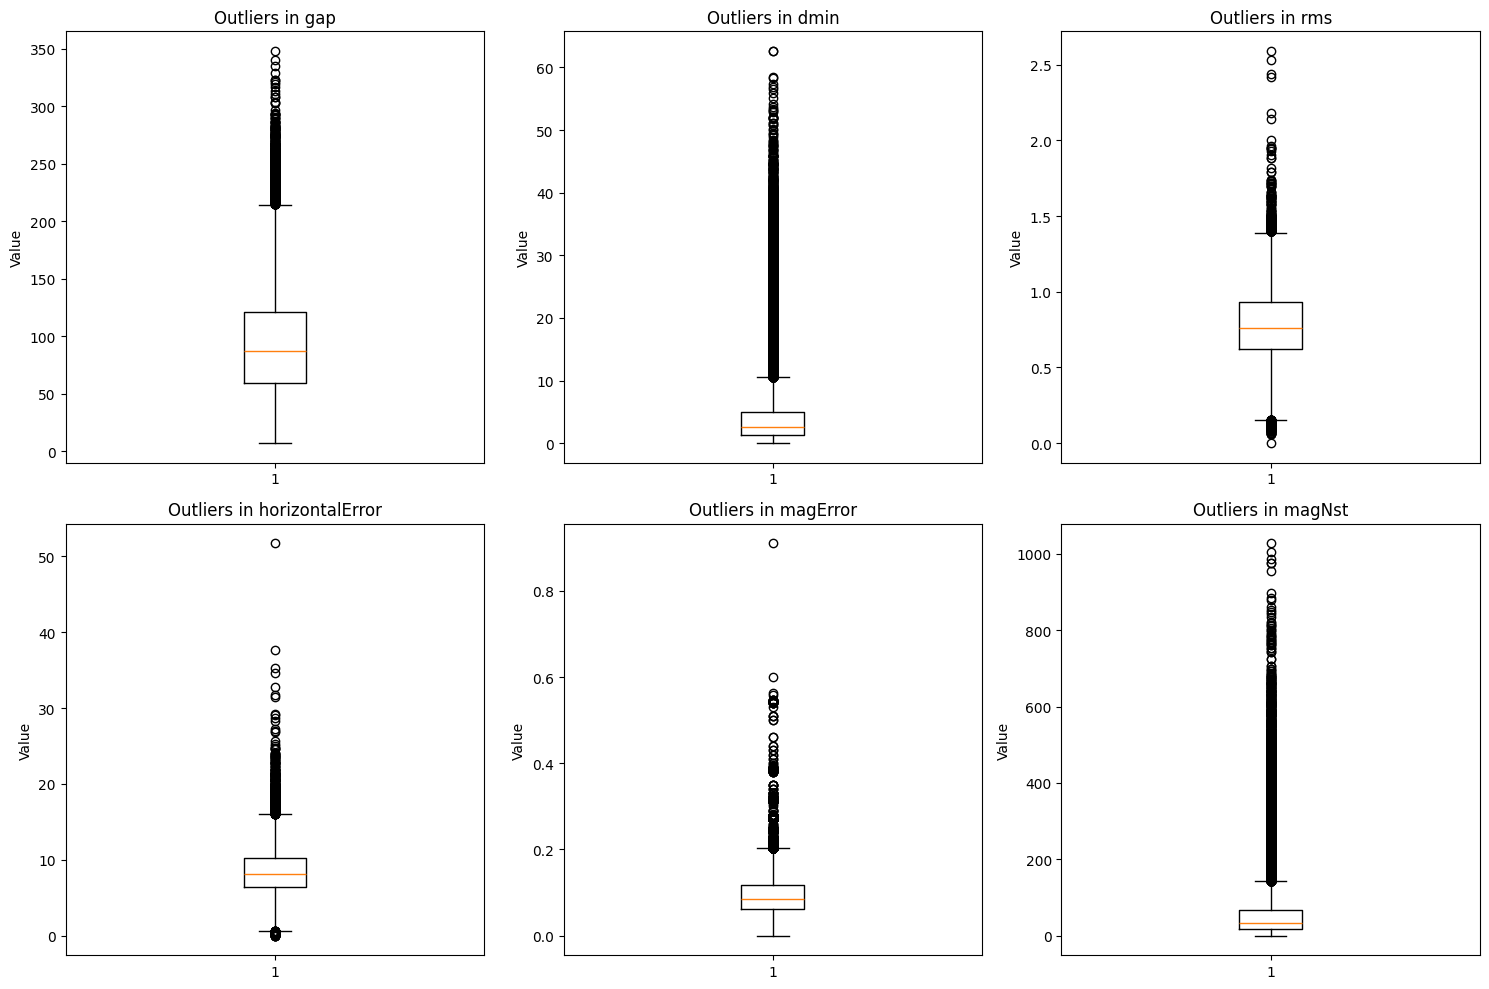

In [51]:
df_clean = raw_data[raw_data['type'] == 'earthquake'].copy()

# Selecting columns that require imputation to check for outliers via Boxplots.
cols_to_visualize = ['gap', 'dmin', 'rms', 'horizontalError', 'magError', 'magNst']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_visualize, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_clean[col].dropna())
    plt.title(f'Outliers in {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.savefig('outlier_justification_plots.png')

# Datetime Transformation & Feature Extraction
df_clean['time'] = pd.to_datetime(df_clean['time'], format='ISO8601', utc=True)
df_clean['year'] = df_clean['time'].dt.year
df_clean['month'] = df_clean['time'].dt.month
df_clean['day'] = df_clean['time'].dt.day
df_clean['hour'] = df_clean['time'].dt.hour

# Textual Data Preprocessing
def extract_country(place):
    if ',' in str(place):
        return place.split(',')[-1].strip()
    else:
        return place.strip()

df_clean['country_region'] = df_clean['place'].apply(extract_country)

# Handling Missing Values
df_clean = df_clean.drop(columns=['nst'])

# Impute numerical columns with the Median. 
for col in cols_to_visualize:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Data Cleaning & Dimensionality Reduction
df_clean = df_clean.drop_duplicates()
cols_to_drop = ['id', 'updated', 'status', 'locationSource', 'magSource', 'net']
df_clean = df_clean.drop(columns=cols_to_drop)


print("--- Preprocessing Complete ---")
print(f"Original Rows: {len(raw_data)}")
print(f"Cleaned Rows: {len(df_clean)}")
print("\nSkewness Statistics for Imputed Columns:")
print(df_clean[cols_to_visualize].skew())

#### Data Preprocessing Summary
To ensure data integrity, we first filtered the dataset to include only natural "earthquake" events, removing non-tectonic noise like explosions that would otherwise distort the physical analysis. Next, we removed the nst column because it contained over 60% missing values, a threshold where imputation becomes unreliable and risks introducing significant synthetic bias. Finally, for the remaining numerical columns, we utilized median imputation instead of the mean; as evidenced by our boxplots, these variables are highly skewed with extreme outliers, making the median a much more robust and representative measure for filling missing data.

# Data Exploration and Analysis
In this section, we explore the preprocessed data to uncover patterns and statistical insights. 
According to the project requirements, we will:
1. Analyze critical statistics and distributions.
2. Perform **Clustering Analysis** to identify seismic zones.
3. Visualize the results using maps and statistical plots.

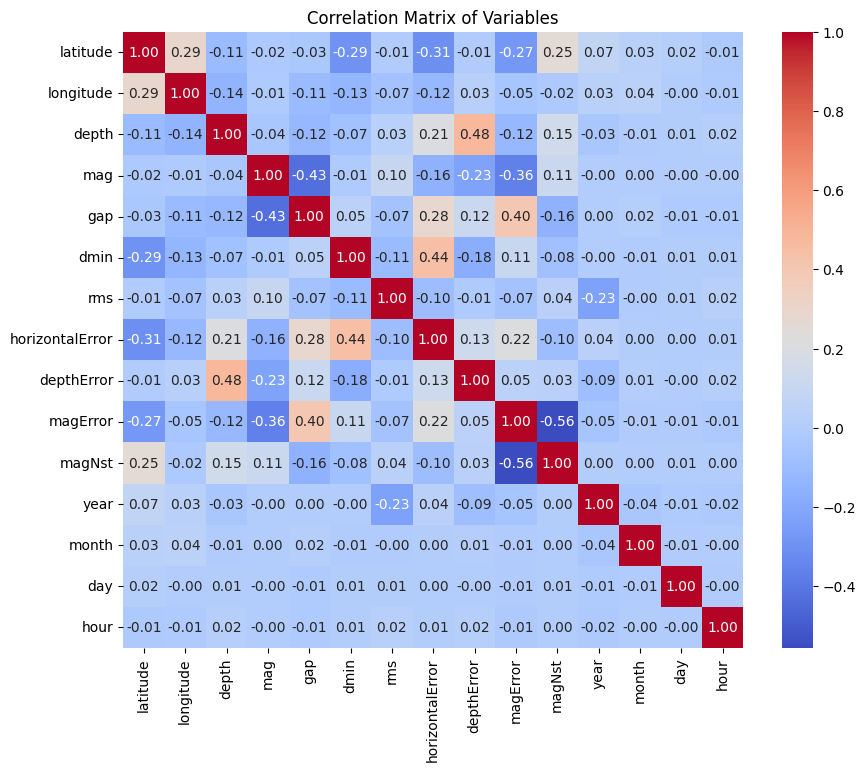

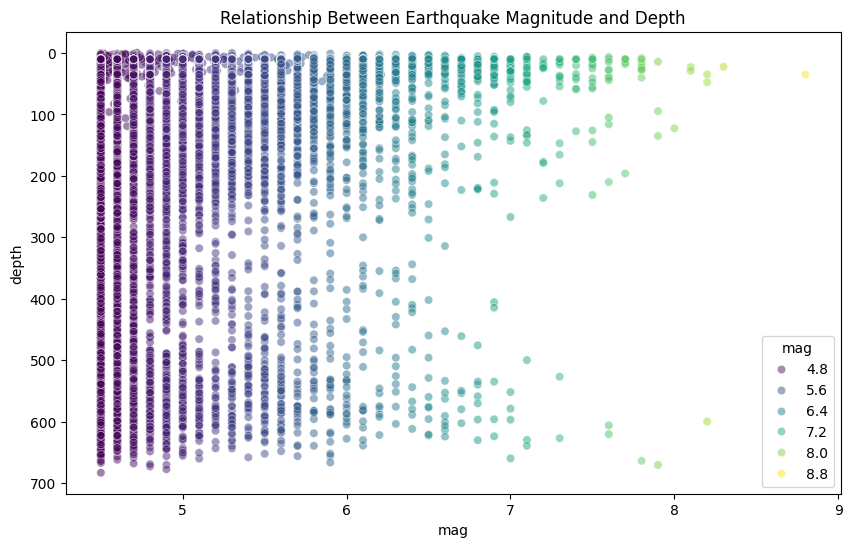

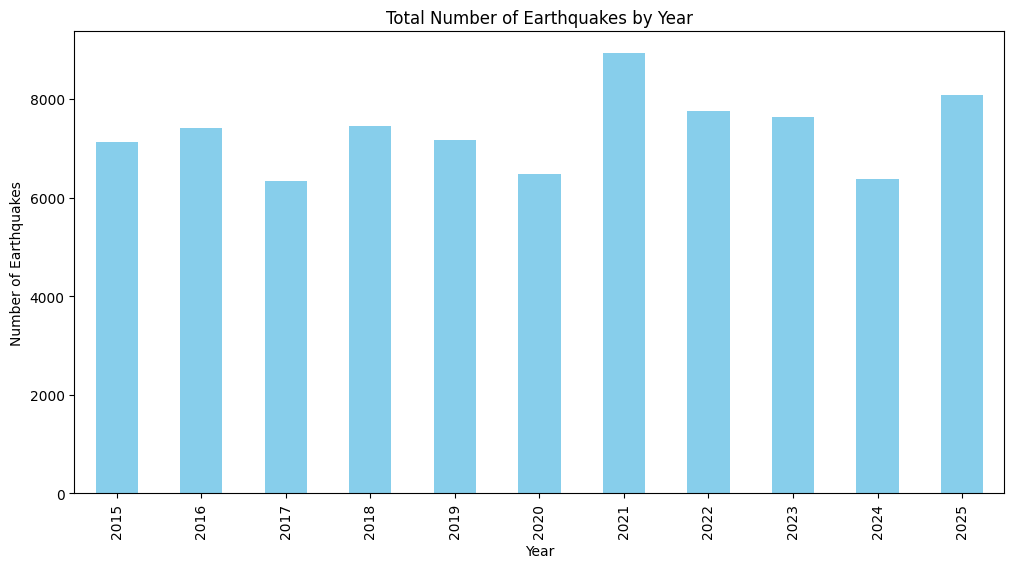

In [52]:
# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Variables')
plt.show()

# 2. Relationship Between Depth and Magnitude
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='mag', y='depth', alpha=0.5, hue='mag', palette='viridis')
plt.title('Relationship Between Earthquake Magnitude and Depth')
plt.gca().invert_yaxis() 
plt.show()

# 3. Number of Earthquakes by Year
plt.figure(figsize=(12, 6))
df_clean['year'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Total Number of Earthquakes by Year')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.show()

Silhouette Score for K=2: 0.3298
Silhouette Score for K=3: 0.3528
Silhouette Score for K=4: 0.3656
Silhouette Score for K=5: 0.3268
Silhouette Score for K=6: 0.3175
Silhouette Score for K=7: 0.3121
Silhouette Score for K=8: 0.3079
Silhouette Score for K=9: 0.3156
Silhouette Score for K=10: 0.3191

Selected Optimal Number of Clusters: 4

--- Statistical Summary per Cluster ---
          mag                 depth               
         mean median  count    mean  median  count
cluster                                           
0        4.72    4.7  25494   38.68   10.00  25494
1        4.75    4.6   3649  523.57  538.76   3649
2        4.70    4.6  43063   41.74   15.01  43063
3        5.61    5.5   8546   38.07   12.17   8546

--- Analysis and Clustering Step Completed ---


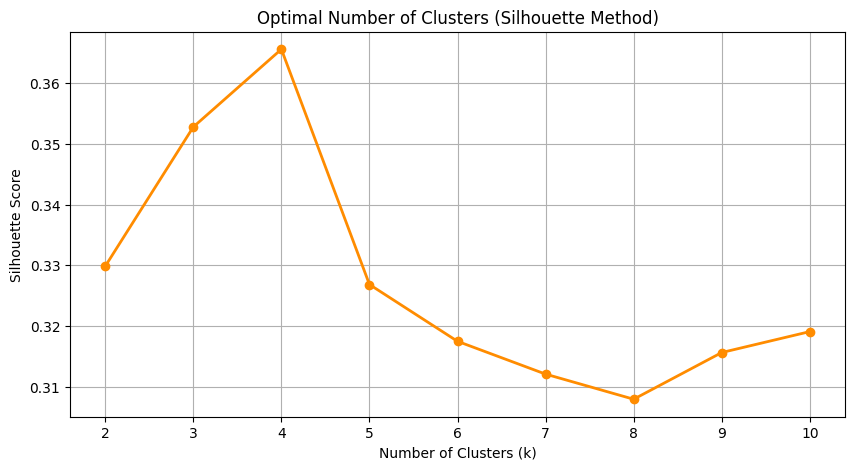

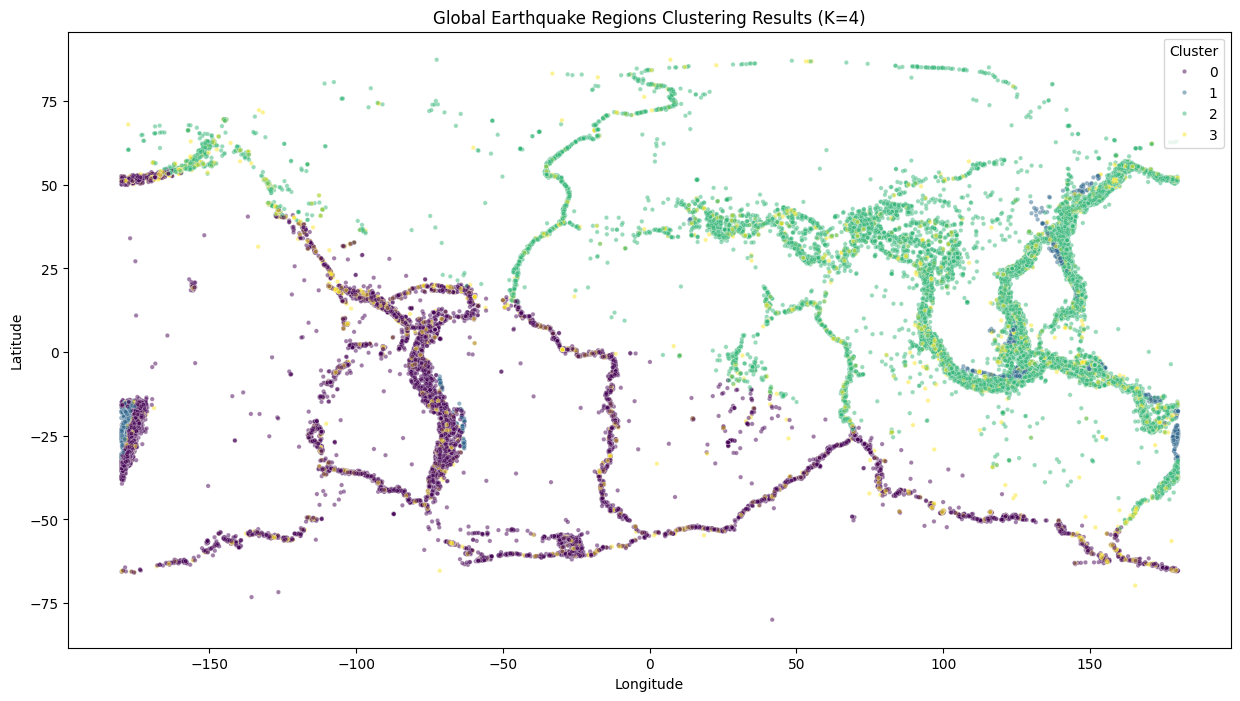

In [53]:
# latitude, longitude, depth, and mag are the parameters that best reflect the earthquake characteristics.
cluster_features = ['latitude', 'longitude', 'depth', 'mag']
X = df_clean[cluster_features]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determining Optimal Number of Clusters (Silhouette Score)
sil_scores = []
k_range = range(2, 11)
sample_size = 10000 # Using a 10000 sample for speed and efficiency.

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=sample_size, random_state=42)
    sil_scores.append(score)
    print(f"Silhouette Score for K={k}: {score:.4f}")

# Silhouette Score Plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, marker='o', color='darkorange', linewidth=2)
plt.title('Optimal Number of Clusters (Silhouette Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('silhouette_analysis.png')

# Training the Final Model on the Entire Dataset
# Find the k value with the highest score
optimal_k = k_range[sil_scores.index(max(sil_scores))]
print(f"\nSelected Optimal Number of Clusters: {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_clean['cluster'] = kmeans_final.fit_predict(X_scaled)


# Visulation Of Cluostering Results
# Geographic Distribution Map
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='cluster', palette='viridis', s=10, alpha=0.5)
plt.title(f'Global Earthquake Regions Clustering Results (K={optimal_k})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster', loc='upper right')
plt.savefig('earthquake_clusters_map.png')

# Statistical Summary of Clusters
cluster_summary = df_clean.groupby('cluster')[['mag', 'depth']].agg(['mean', 'median', 'count']).round(2)
print("\n--- Statistical Summary per Cluster ---")
print(cluster_summary)
print("\n--- Analysis and Clustering Step Completed ---")

In this phase of the project, we conducted a comprehensive Exploratory Data Analysis and unsupervised learning to decode global seismic patterns. We began by generating a correlation matrix to identify interdependencies between numerical variables, followed by visualizing the relationship between earthquake magnitude and depth to capture the physical profile of seismic events. To ensure temporal consistency, we analyzed the frequency of earthquakes over the past decade using a yearly distribution bar chart. Subsequently, we implemented a K-Means clustering algorithm, utilizing the Silhouette Method with a 10,000-point sampling strategy to scientifically determine the optimal number of clusters ($k$). By clustering the data based on latitude, longitude, depth, and magnitude, we successfully identified distinct seismic zones that align with global tectonic structures, providing a refined and labeled dataset ready for subsequent predictive modeling.

# Predictive Modelling
In this stage, we build classification models to predict the magnitude category (`mag_class`) of an earthquake based on its seismic and geographical features.

**Algorithms Used:**
1. **Logistic Regression**: A baseline linear model for multiclass classification.
2. **K-Nearest Neighbors (KNN)**: A distance-based non-parametric algorithm.
3. **Decision Tree**: A tree-structured model that handles non-linear relationships well.

**Workflow:**
- Feature Selection & Encoding
- Data Splitting (Train/Test/Validation)
- Model Training & Hyperparameter Discussion
- Performance Comparison

Training Set: 48450 | Validation Set: 16151 | Test Set: 16151

--- Validation Set Accuracy Scores ---
Logistic Regression: 0.8432
KNN (k=9): 0.8512
Decision Tree (depth=5): 0.8565

Selected Best Model: Decision Tree (depth=5)

--- FINAL TEST SET REPORT (Decision Tree (depth=5)) ---
              precision    recall  f1-score   support

       Major       1.00      0.04      0.08       281
    Moderate       0.86      1.00      0.92     12379
      Strong       0.85      0.42      0.56      3491

    accuracy                           0.86     16151
   macro avg       0.90      0.49      0.52     16151
weighted avg       0.86      0.86      0.83     16151



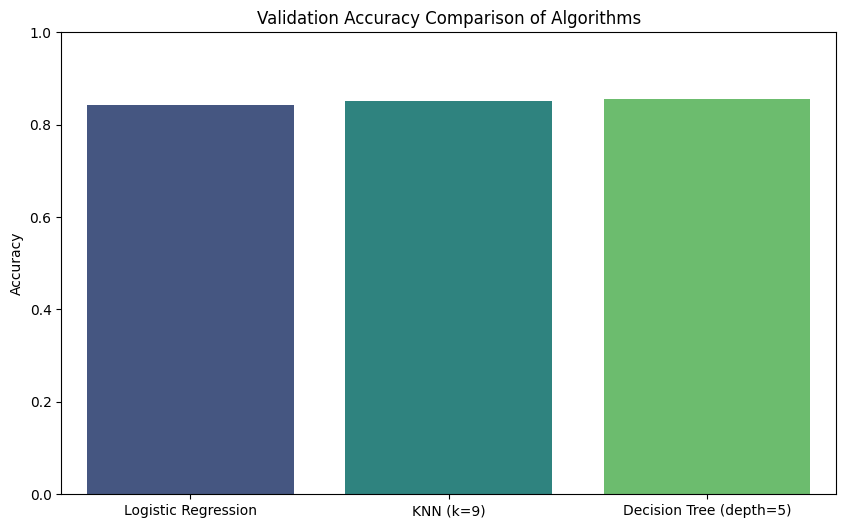

In [54]:

# Categorizing the Target Variable 
# Categorize the 'mag' (magnitude) value into groups for classification:
def categorize_mag(mag):
    if mag < 5:
        return "Moderate"
    elif mag < 6:
        return "Strong"
    else:
        return "Major"

df_clean['mag_class'] = df_clean['mag'].apply(categorize_mag)

# Features and Target
features = ['latitude', 'longitude', 'depth', 'year', 'cluster']
X = df_clean[features]
y = df_clean['mag_class']

# Data Splitting (60% Train, 20% Validation, 20% Test)
# First, split into 80% train+val and 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Then, split the 80% portion into 75% training and 25% validation (Resulting in 60-20-20 total)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

print(f"Training Set: {len(X_train)} | Validation Set: {len(X_val)} | Test Set: {len(X_test)}")

# Feature Scaling
# Essential for Logistic Regression and KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

results = {}

# Logistic Regression (Parameter: C - Regularization strength)
log_reg = LogisticRegression(max_iter=1000, C=1.0)
log_reg.fit(X_train_scaled, y_train)
val_pred_lr = log_reg.predict(X_val_scaled)
results['Logistic Regression'] = accuracy_score(y_val, val_pred_lr)

# K-Nearest Neighbors (KNN) (Parameter Selection: k value)
# Finding the best k value on the validation set:
best_k = 0
best_knn_score = 0
for k in range(3, 11, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = accuracy_score(y_val, knn.predict(X_val_scaled))
    if score > best_knn_score:
        best_knn_score = score
        best_k = k

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
results[f'KNN (k={best_k})'] = best_knn_score

# Decision Tree (Parameter Selection: max_depth)
best_depth = 0
best_dt_score = 0
for depth in [5, 10, 15, 20]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train) 
    score = accuracy_score(y_val, dt.predict(X_val))
    if score > best_dt_score:
        best_dt_score = score
        best_depth = depth

dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)
results[f'Decision Tree (depth={best_depth})'] = best_dt_score

# PERFORMANCE COMPARISON AND TESTING
print("\n--- Validation Set Accuracy Scores ---")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

# MODEL EVALUATION AND BEST MODEL SELECTION
# Identify the best model name and its score based on validation accuracy
best_model_name = max(results, key=results.get)
print(f"\nSelected Best Model: {best_model_name}")

# Assign the actual model object and the correct test data
# KNN and Logistic Regression require scaled data (X_test_scaled), while Decision Trees typically perform better or equally well on unscaled data (X_test).
if "Decision Tree" in best_model_name:
    final_model = dt_final
    X_test_to_use = X_test  
elif "KNN" in best_model_name:
    final_model = knn_final
    X_test_to_use = X_test_scaled  
else:
    final_model = log_reg
    X_test_to_use = X_test_scaled  

# Perform Final Prediction on the Test Set
y_test_pred = final_model.predict(X_test_to_use) 

# Generate the Final Performance Report
print(f"\n--- FINAL TEST SET REPORT ({best_model_name}) ---")
print(classification_report(y_test, y_test_pred))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Validation Accuracy Comparison of Algorithms')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

In this classification stage, we aim to predict earthquake magnitude by grouping it into three categories: Moderate, Strong, and Major. To ensure the model is reliable, we split the data into three parts: 60% for training, 20% for validation (tuning), and 20% for final testing. We compared three different algorithms: Logistic Regression, which serves as a simple baseline; K-Nearest Neighbors (KNN), where we tested different values of $k$ to find the best local patterns; and Decision Tree, where we adjusted the maximum depth to ensure the model doesn't just memorize the data (overfitting). By testing these models on the validation set, we identified the best-performing one and then ran it on the final test set. This process allows us to provide a clear performance report and ensures our earthquake predictions are accurate and trustworthy across all categories.

# Model Evaluation and Visualizations
In this final step, we evaluate the performance of our three models using more detailed metrics than simple accuracy. 
Since our dataset is imbalanced (more 'Moderate' than 'Major' earthquakes), we focus on:
1. **Confusion Matrix**: To see exactly which classes are being misclassified.
2. **Classification Report**: To analyze Precision, Recall, and F1-Score for each magnitude class.
3. **ROC Curves**: To visualize the trade-off between true positive and false positive rates.

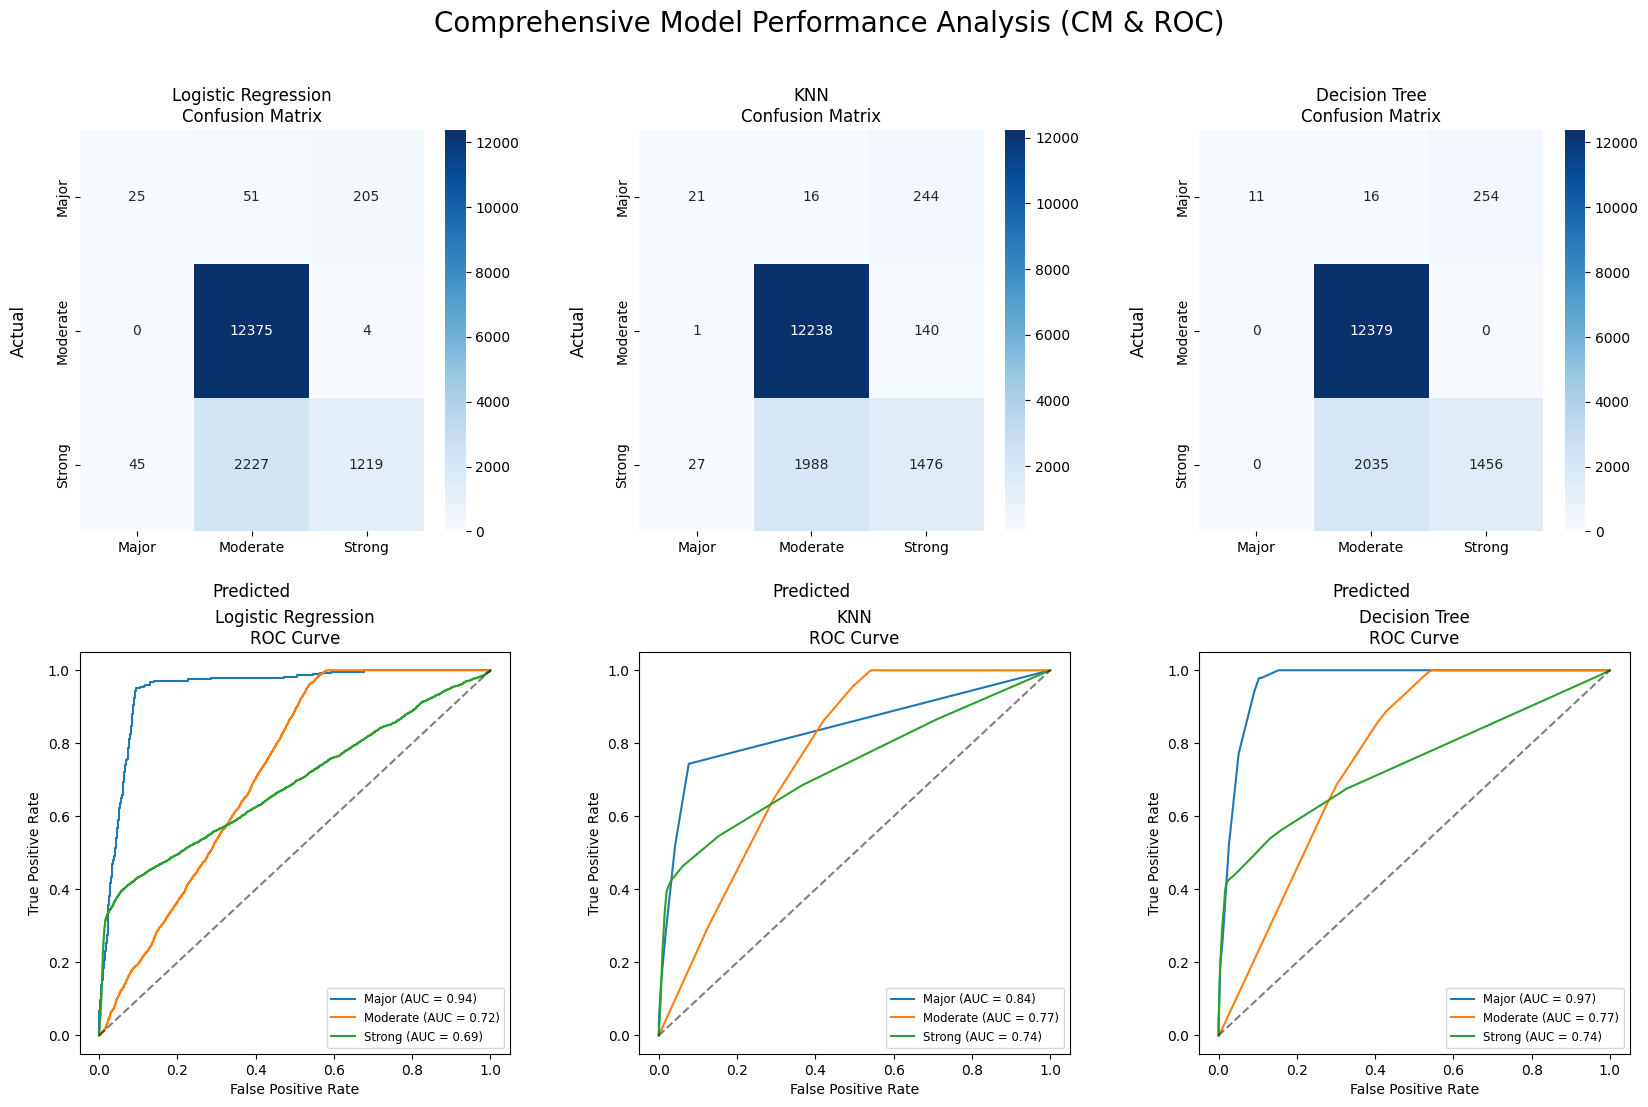


--- Final Test Set Performance Table ---
              Model  F1-Score (Macro)
Logistic Regression          0.517887
                KNN          0.532790
      Decision Tree          0.519577


In [55]:
# Define models and their corresponding test data
models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'KNN': (knn_final, X_test_scaled),
    'Decision Tree': (dt_final, X_test)
}

# Binarize classes for ROC curve calculation
# This uses the sorted class names: ['Major', 'Moderate', 'Strong']
all_classes = sorted(df_clean['mag_class'].unique())
n_classes = len(all_classes)
y_test_binarized = label_binarize(y_test, classes=all_classes)

# Visualization Panel 
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

for i, (name, (model, X_input)) in enumerate(models.items()):
    y_pred = model.predict(X_input)
    y_score = model.predict_proba(X_input)

    # CONFUSION MATRIX 
    cm = confusion_matrix(y_test, y_pred, labels=all_classes)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i],
                xticklabels=all_classes, yticklabels=all_classes)
    
    axes[0, i].set_title(f'{name}\nConfusion Matrix')
    axes[0, i].set_xlabel('Predicted', fontsize=12, labelpad=20) 
    axes[0, i].set_ylabel('Actual', fontsize=12, labelpad=20)

    # ROC CURVE
    for j in range(n_classes):
        if n_classes == 2:
            fpr, tpr, _ = roc_curve(y_test == all_classes[j], y_score[:, j])
        else:
            fpr, tpr, _ = roc_curve(y_test_binarized[:, j], y_score[:, j])
            
        roc_auc = auc(fpr, tpr)
        axes[1, i].plot(fpr, tpr, label=f'{all_classes[j]} (AUC = {roc_auc:.2f})')
    
    axes[1, i].plot([0, 1], [0, 1], 'k--', alpha=0.5) 
    axes[1, i].set_title(f'{name}\nROC Curve')
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].legend(loc="lower right", fontsize='small')

plt.suptitle('Comprehensive Model Performance Analysis (CM & ROC)', fontsize=20, y=0.98)
plt.show()

# SUMMARY PERFORMANCE TABLE 
final_performance = []
for name, (model, X_input) in models.items():
    y_pred = model.predict(X_input)
    final_performance.append({
        'Model': name,
        'F1-Score (Macro)': f1_score(y_test, y_pred, average='macro')
    })

performance_df = pd.DataFrame(final_performance)
print("\n--- Final Test Set Performance Table ---")
print(performance_df.to_string(index=False))

To evaluate our classification models thoroughly, we used several performance metrics and visual tools to check how well they predict different earthquake sizes. We created Confusion Matrices for each algorithm to see exactly which seismic events were classified correctly and where the models got confused between Moderate, Strong, and Major categories. To understand how well the models tell these classes apart at different levels, we drew ROC Curves and calculated the Area Under the Curve (AUC) for each category. Additionally, we used the Macro F1-Score to get a balanced performance score that treats every category as equally important, even if some categories appear more often than others. By combining these visual charts with numerical scores, we made sure our final model is both accurate and reliable for predicting all earthquake intensities

# Comprehensive Project Report: Earthquake Classification & Analysis

---

## Part 1: Data Cleaning and Preprocessing

To ensure **data integrity** and **physical validity**, a series of preprocessing steps were applied before any analysis or modeling.

### Event Filtering

* The dataset was filtered to include **only natural `earthquake` events**.
* Non-tectonic events such as **explosions** were removed to prevent distortion of seismic patterns and physical interpretations.

### Handling Missing Values

* The **`nst`** column was removed entirely because it contained **more than 60% missing values**.

  * At this level of sparsity, imputation becomes unreliable and introduces a high risk of synthetic bias.

### Imputation Strategy

* For the remaining numerical features, **median imputation** was applied.
* This choice was motivated by:

  * Highly **skewed distributions**
  * Presence of **extreme outliers**, as confirmed by boxplot visualizations
* The median provides a more **robust and representative** measure than the mean under such conditions.

---

## Part 2: Exploratory Data Analysis (EDA) and Clustering

This phase focused on uncovering global seismic patterns through visualization and unsupervised learning techniques.

### Exploratory Data Analysis

* A **correlation matrix** was generated to examine dependencies among numerical variables.
* The relationship between **earthquake magnitude and depth** was visualized to capture the physical structure of seismic events.
* To ensure **temporal consistency**, earthquake frequency over the **past decade** was analyzed using a yearly distribution bar chart.

### Clustering Analysis

* A **K-Means clustering** algorithm was implemented to identify natural groupings in seismic data.
* The **Silhouette Method** was employed to determine the optimal number of clusters:

  * A **10,000-point sampling strategy** was used to ensure computational efficiency without sacrificing reliability.

### Feature Selection for Clustering

* Clustering was performed using the following features:

  * Latitude
  * Longitude
  * Depth
  * Magnitude

### Results

* The resulting clusters revealed **distinct seismic zones** that align closely with known **global tectonic structures**.
* This process produced a **refined and labeled dataset**, suitable for downstream predictive modeling tasks.

---

## Part 3: Predictive Modelling

The objective of this stage was to **predict earthquake magnitude categories** using supervised learning techniques.

### Target Definition

* Earthquake magnitudes were categorized into three classes:

  * **Moderate**
  * **Strong**
  * **Major**

### Data Splitting Strategy

* The dataset was divided using a **60–20–20 split**:

  * **Training set**: Model learning
  * **Validation set**: Hyperparameter tuning and model selection
  * **Test set**: Final unbiased evaluation

### Implemented Models

* **Logistic Regression**

  * Served as a simple **linear baseline** model.

* **K-Nearest Neighbors (KNN)**

  * Used to capture **local patterns** in the data.
  * Multiple values of (k) were tested to find the optimal neighborhood size.

* **Decision Tree**

  * Tuned by adjusting the **maximum depth** parameter.
  * This prevented overfitting by limiting the model’s tendency to memorize the training data.

### Model Selection

* Performance on the **validation set** was used to identify the best-performing algorithm for final evaluation.

---

## Part 4: Model Evaluation and Visualizations

A comprehensive evaluation framework was used to assess classification performance and reliability.

### Evaluation Metrics

* **Confusion Matrices** were generated for each model to:

  * Visualize correct classifications
  * Identify common misclassification patterns among magnitude categories

* **ROC Curves** and **Area Under the Curve (AUC)** scores were computed:

  * Evaluated the models’ ability to distinguish between classes at varying thresholds
  * Calculated separately for each magnitude category

* **Macro F1-Score** was used as the primary summary metric:

  * Treats all classes **equally**, regardless of class imbalance
  * Provides a balanced measure of precision and recall

### Final Assessment

* By combining:

  * Visual diagnostics (confusion matrices, ROC curves)
  * Quantitative metrics (AUC, Macro F1-score)

We confirmed that the final selected model is both **accurate** and **robust** for predicting seismic intensity categories across diverse earthquake events.
